# (노트) 파이토치 - torch.utils.data

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [딥러닝]

### import 

In [4]:
import torch
import torchvision
#from torch.utils.data import Dataset
#from torchvision import datasets
#from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

### torch.utils.data.dataset

In [5]:
X=torch.tensor([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
y=torch.tensor([1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0])

In [7]:
X,y

(tensor([3., 4., 5., 6., 7., 8., 9.]), tensor([1., 0., 1., 0., 1., 1., 0.]))

In [28]:
ds = torch.utils.data.dataset.TensorDataset(X,y)
type(ds)

torch.utils.data.dataset.TensorDataset

In [30]:
torch.utils.data.dataset

Init signature: torch.utils.data.dataset.ChainDataset(*args, **kwds)
Docstring:     
Dataset for chaining multiple :class:`IterableDataset` s.

This class is useful to assemble different existing dataset streams. The
chaining operation is done on-the-fly, so concatenating large-scale
datasets with this class will be efficient.

Args:
    datasets (iterable of IterableDataset): datasets to be chained together
File:           ~/anaconda3/envs/py37/lib/python3.7/site-packages/torch/utils/data/dataset.py
Type:           type
Subclasses:     


### torch.utils.data.dataloader

In [27]:
dl = torch.utils.data.dataloader.DataLoader(ds,batch_size=2,shuffle=True)
type(dl)

torch.utils.data.dataloader.DataLoader

### load data

In [4]:
training_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

- root is the path where the train/test data is stored,
- train specifies training or test dataset,
- download=True downloads the data from the internet if it’s not available at root.
- transform and target_transform specify the feature and label transformations


In [5]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
type(training_data), type(test_data)

(torchvision.datasets.mnist.FashionMNIST,
 torchvision.datasets.mnist.FashionMNIST)

### torchvision.datasets.mnist.FashionMNIST의 기능을 살펴보자. 

`-` class_to_idx

In [8]:
training_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

`-` classes

In [9]:
training_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

`-` data

In [10]:
training_data.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

`-` mirror?

In [11]:
training_data.mirrors #?? 

['http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/']

`-` processed_folder

In [12]:
training_data.processed_folder

'data/FashionMNIST/processed'

`-` raw_folder

In [13]:
training_data.raw_folder

'data/FashionMNIST/raw'

`-` resources ???

In [14]:
training_data.resources

[('train-images-idx3-ubyte.gz', '8d4fb7e6c68d591d4c3dfef9ec88bf0d'),
 ('train-labels-idx1-ubyte.gz', '25c81989df183df01b3e8a0aad5dffbe'),
 ('t10k-images-idx3-ubyte.gz', 'bef4ecab320f06d8554ea6380940ec79'),
 ('t10k-labels-idx1-ubyte.gz', 'bb300cfdad3c16e7a12a480ee83cd310')]

`-` root

In [15]:
training_data.root

'data'

`-` target_transform

In [16]:
training_data.target_transform

`-` targets

In [17]:
training_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

`-` test_data

In [18]:
training_data.test_data

/home/cgb3/anaconda3/envs/py39/lib/python3.9/site-packages/torchvision/datasets/mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")


tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [19]:
training_data.data.shape, training_data.test_data.shape

(torch.Size([60000, 28, 28]), torch.Size([60000, 28, 28]))

In [20]:
id(training_data.data.shape), id(training_data.test_data.shape)

(139926582008384, 139926582008384)

`-` test_file

In [21]:
training_data.test_file

'test.pt'

`-` test_labels

In [22]:
training_data.test_labels

/home/cgb3/anaconda3/envs/py39/lib/python3.9/site-packages/torchvision/datasets/mnist.py:70: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


tensor([9, 0, 0,  ..., 3, 0, 5])

In [23]:
id(training_data.targets), id(training_data.test_labels)

(139926582306992, 139926582306992)

`-` training_file

In [24]:
training_data.training_file

'training.pt'

`-` transform

In [25]:
training_data.transform

ToTensor()

In [26]:
type(training_data.transform)

torchvision.transforms.transforms.ToTensor

In [27]:
set(dir(training_data.transform)) & {'__call__'}

{'__call__'}

In [28]:
training_data.transform?

Signature:      training_data.transform(pic)
Type:           ToTensor
String form:    ToTensor()
File:           ~/anaconda3/envs/py39/lib/python3.9/site-packages/torchvision/transforms/transforms.py
Docstring:     
Convert a ``PIL Image`` or ``numpy.ndarray`` to tensor. This transform does not support torchscript.

Converts a PIL Image or numpy.ndarray (H x W x C) in the range
[0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
if the PIL Image belongs to one of the modes (L, LA, P, I, F, RGB, YCbCr, RGBA, CMYK, 1)
or if the numpy.ndarray has dtype = np.uint8

In the other cases, tensors are returned without scaling.

.. note::
    Because the input image is scaled to [0.0, 1.0], this transformation should not be used when
    transforming target image masks. See the `references`_ for implementing the transforms for image masks.

.. _references: https://github.com/pytorch/vision/tree/main/references/segmentation
Call docstring:
Args:
    pic (PIL Image or nump

- PIL Image or numpy 를 Tensor로 바꾸는 역할을 하는 함수인듯 

`-` transforms

In [29]:
training_data.transforms

StandardTransform
Transform: ToTensor()

In [30]:
type(training_data.transforms)

torchvision.datasets.vision.StandardTransform

In [31]:
type(training_data.transform), type(training_data.transforms)

(torchvision.transforms.transforms.ToTensor,
 torchvision.datasets.vision.StandardTransform)

In [32]:
set(dir(training_data.transforms)) & {'__call__'}

{'__call__'}

In [33]:
training_data.transforms?

Signature:   training_data.transforms(input: Any, target: Any) -> Tuple[Any, Any]
Type:        StandardTransform
String form:
StandardTransform
Transform: ToTensor()
File:        ~/anaconda3/envs/py39/lib/python3.9/site-packages/torchvision/datasets/vision.py
Docstring:   <no docstring>


- X,y를 튜플로 묶어주는 역할을 함. 

`-` 인덱싱가능 

In [34]:
# 
# training_data[0] ## 튜플
print(training_data[0][0].shape)
print(training_data[0][1])

torch.Size([1, 28, 28])
9


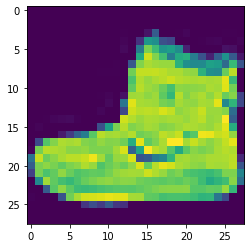

In [35]:
# 
# 시각화방법1
plt.imshow(training_data[0][0].reshape(28,28))

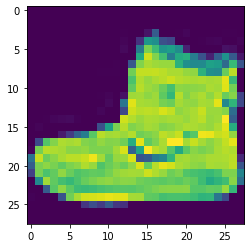

In [36]:
# 
# 시각화방법2
plt.imshow(training_data[0][0].squeeze())

`-` len 가능

In [37]:
len(training_data)

60000

### 데이터를 순회하고 시각화

In [38]:
training_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [39]:
training_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [40]:
{i:training_data.classes[i] for i in range(10)}

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

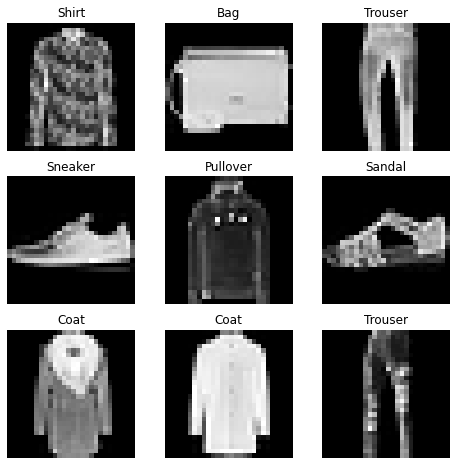

In [41]:
labels_map = {i:training_data.classes[i] for i in range(10)}
# labels_map = {
#     0: "T-Shirt",
#     1: "Trouser",
#     2: "Pullover",
#     3: "Dress",
#     4: "Coat",
#     5: "Sandal",
#     6: "Shirt",
#     7: "Sneaker",
#     8: "Bag",
#     9: "Ankle Boot",
# }
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()